# 04 · Comparación final y diagnóstico de la destilación

Reúne todos los runs registrados (docentes, estudiantes y destilados) y responde
si la destilación sirvió: no solo si el macro-F1 subió, sino dónde cambió y por
qué.

In [ ]:
import os
import subprocess
import sys
from pathlib import Path

if Path("/kaggle").exists():
    from kaggle_secrets import UserSecretsClient

    CLON = "/tmp/ButterflyModeling"
    AYUDA = "!f() { echo username=x-access-token; echo password=$GITHUB_TOKEN; }; f"
    os.environ["GITHUB_TOKEN"] = UserSecretsClient().get_secret("GITHUB_TOKEN")
    if not Path(CLON).exists():
        subprocess.run(["git", "-c", f"credential.helper={AYUDA}", "clone",
                        "https://github.com/CCSandoval/ButterflyModeling.git", CLON], check=True)
    sys.path.insert(0, CLON)
    os.chdir(CLON)
    print("clon en", CLON, "·", subprocess.run(
        ["git", "log", "-1", "--format=%h %s"], cwd=CLON,
        capture_output=True, text=True).stdout.strip())

In [9]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "corpus.json").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Raíz del proyecto:", ROOT)

Raíz del proyecto: /Users/cristiansandoval/Universidad/Semillero/ButterflyModeling


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from scripts import corpus, evalStats
from scripts import modelRegistry as registro
from scripts.vizStyle import (CMAP_AZUL, INK_MUTED, SERIE_1, SERIE_2, SERIE_3,
                              applyStyle)

# MARGEN_F1 = 0.05

## 1 · Todos los runs

In [11]:
filas = []
for run in registro.listRuns():
    print(f"Procesando run_id={run['run_id']}...")
    ruta = registro.rutaModelo(run["run_id"])
    if not ruta.exists():
        continue
    modelo = tf.keras.models.load_model(ruta)
    filas.append({
        "rol": run.get("role", "?"),
        "arquitectura": run["architecture"],
        "test_macro_f1": run["test_macro_f1"],
        "test_accuracy": run["test_accuracy"],
        "parametros_M": round(modelo.count_params() / 1e6, 2),
        "tamano_MB": round(ruta.stat().st_size / 1e6, 1),
        "latencia_ms": round(evalStats.medirLatencia(modelo), 1),
        "minutos": run["training_minutes"],
        "run_id": run["run_id"],
    })

todos = pd.DataFrame(filas).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
todos.drop(columns="run_id")

Procesando run_id=20260928T000655Z_kd-features-mobilenet-v3-small...
Procesando run_id=20260927T155609Z_kd-respuesta-ft-mobilenet-v3-small...
Procesando run_id=20260916T025430Z_kd-respuesta-mobilenet-v3-small...
Procesando run_id=20260915T015250Z_inception-v3...
Procesando run_id=20260914T021232Z_densenet121...
Procesando run_id=20260913T104733Z_resnet50-v2...
Procesando run_id=20260913T005433Z_efficientnet-v2-s...
Procesando run_id=20260912T180552Z_nasnet-mobile...
Procesando run_id=20260912T131459Z_efficientnet-b0...
Procesando run_id=20260912T122558Z_mobilenet-v2...
Procesando run_id=20260912T044001Z_mobilenet-v3-small...
Procesando run_id=20260912T001248Z_efficientnet-v2-b0...
Procesando run_id=20260908T012953Z_efficientnet-v2-s...
Procesando run_id=20260907T014314Z_efficientnet-v2-b0...
Procesando run_id=20260906T211535Z_nasnet-mobile...
Procesando run_id=20260906T173406Z_efficientnet-b0...
Procesando run_id=20260906T151143Z_mobilenet-v2...
Procesando run_id=20260906T040431Z_incep

,rol,arquitectura,test_macro_f1,test_accuracy,parametros_M,tamano_MB,latencia_ms,minutos
0,docente,efficientnet_v2_s,0.913467,0.914161,21.17,175.7,256.1,529.1
1,estudiante,efficientnet_b0,0.900388,0.902522,4.88,51.5,109.4,243.0
2,docente,densenet121,0.890166,0.890883,7.74,61.0,201.4,573.7
3,docente,efficientnet_v2_b0,0.888289,0.889913,6.75,59.2,111.7,209.1
4,docente,inception_v3,0.882367,0.887003,23.03,210.8,146.3,384.9
5,estudiante,nasnet_mobile,0.861428,0.866149,4.99,52.4,234.2,303.4
6,estudiante,mobilenet_v3_small,0.842630,0.846266,1.41,15.9,47.1,64.9
7,destilado,mobilenet_v3_small,0.826830,0.832687,1.41,6.2,44.9,465.6
8,docente,efficientnet_v2_b0,0.820501,0.831717,6.75,34.7,116.0,179.4
9,estudiante,efficientnet_b0,0.815861,0.827352,4.88,27.1,111.0,207.2


## 2 · Calidad vs costo

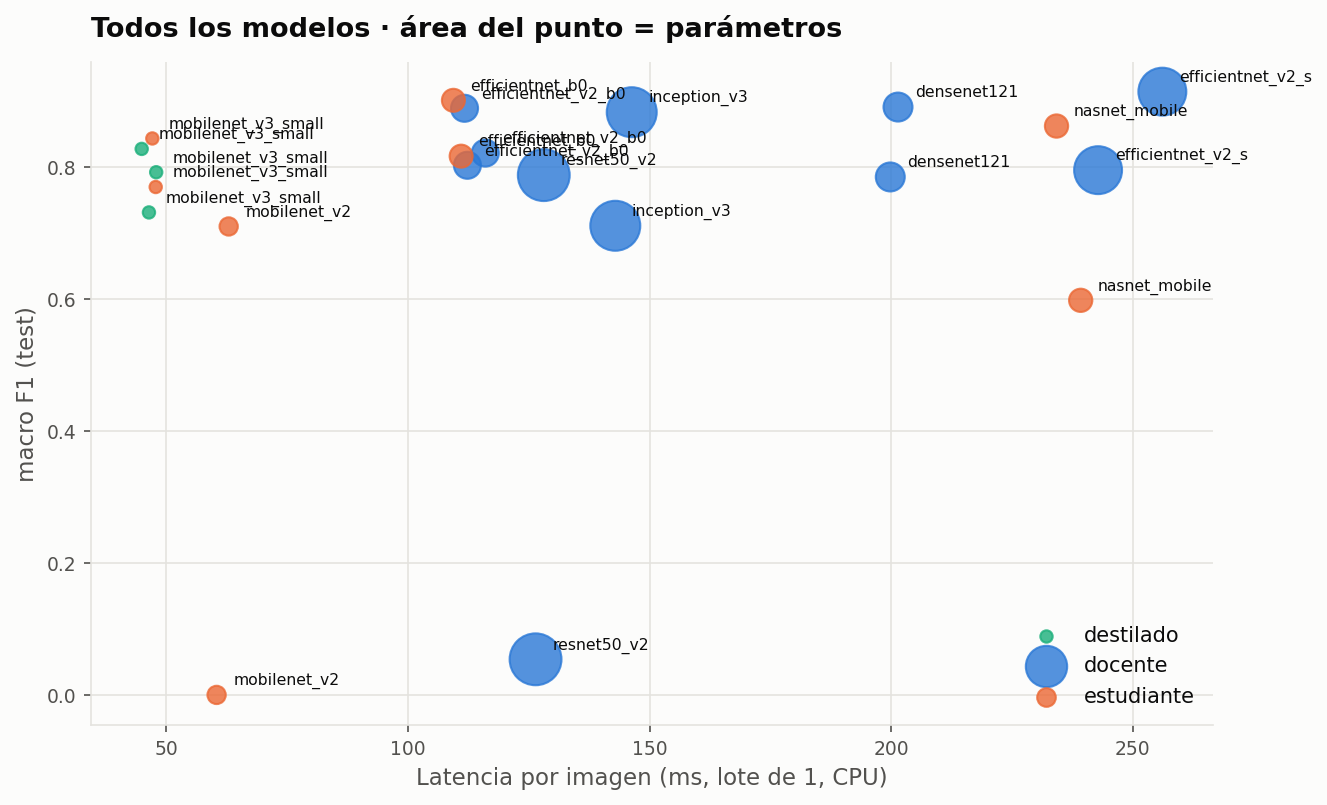

In [12]:
applyStyle()
COLOR_ROL = {"docente": SERIE_1, "estudiante": SERIE_2, "destilado": SERIE_3}

fig, ax = plt.subplots(figsize=(9, 5.5))
for rol, grupo in todos.groupby("rol"):
    ax.scatter(grupo["latencia_ms"], grupo["test_macro_f1"], s=grupo["parametros_M"] * 25,
               color=COLOR_ROL.get(rol, INK_MUTED), alpha=0.8, label=rol, zorder=3)
for _, f in todos.iterrows():
    ax.annotate(f["arquitectura"], (f["latencia_ms"], f["test_macro_f1"]),
                textcoords="offset points", xytext=(8, 5), fontsize=7.5)
ax.set(xlabel="Latencia por imagen (ms, lote de 1, CPU)", ylabel="macro F1 (test)",
       title="Todos los modelos · área del punto = parámetros")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## 3 · ¿Sirvió la destilación?

El control es el run sin destilar del mismo estudiante, así que el único
factor que cambia es el docente.

In [13]:
destilados = todos[todos["rol"] == "destilado"]
assert len(destilados), "sin runs destilados todavía"

comparaciones = []
for _, dest in destilados.iterrows():
    cfg = registro.loadRunConfig(dest["run_id"])
    docente = registro.findRun(cfg["distillation"]["teacher_run_id"])
    # el control comparte arquitectura Y grado de descongelado: si no, se
    # compararía fine-tuning contra backbone congelado y no solo el efecto del docente
    control = next(r for r in registro.listRuns()
                   if r["architecture"] == dest["arquitectura"]
                   and not r.get("teacher_run_id")
                   and r.get("finetuning", 0.0) == cfg.get("finetuning", 0.0))
    comparaciones.append({
        "destilado": dest["run_id"],
        "estudiante": dest["arquitectura"],
        "tipo": cfg["distillation"]["tipo"],
        "finetuning": cfg.get("finetuning", 0.0),
        "T": cfg["distillation"]["temperatura"],
        "alfa": cfg["distillation"]["alfa"],
        "f1_control": control["test_macro_f1"],
        "f1_destilado": dest["test_macro_f1"],
        "f1_docente": docente["test_macro_f1"],
        "delta": dest["test_macro_f1"] - control["test_macro_f1"],
        "brecha": docente["test_macro_f1"] - control["test_macro_f1"],
        "min_control": control["training_minutes"],
        "min_destilado": dest["minutos"],
    })

resumen = pd.DataFrame(comparaciones)
for _, r in resumen.iterrows():
    signo = "mejora" if r["delta"] > 0 else "empeora"
    print(f"{r['tipo']:12} T={r['T']} alfa={r['alfa']}  {signo} {abs(r['delta']):.4f} de macro-F1")
    print(f"  control {r['f1_control']:.4f} -> destilado {r['f1_destilado']:.4f} "
          f"(docente {r['f1_docente']:.4f}, brecha {r['brecha']:+.4f})")
    print(f"  costo: {r['min_control']:.0f} min -> {r['min_destilado']:.0f} min "
          f"({r['min_destilado']/r['min_control']:.1f}x)")
resumen[["tipo", "finetuning", "T", "alfa", "f1_control", "f1_destilado", "f1_docente", "delta"]]

respuesta    T=4.0 alfa=0.7  mejora 0.0577 de macro-F1
  control 0.7691 -> destilado 0.8268 (docente 0.9135, brecha +0.1443)
  costo: 61 min -> 466 min (7.6x)
features     T=4.0 alfa=0.7  mejora 0.0224 de macro-F1
  control 0.7691 -> destilado 0.7915 (docente 0.9135, brecha +0.1443)
  costo: 61 min -> 505 min (8.3x)
respuesta    T=4.0 alfa=0.7  empeora 0.0385 de macro-F1
  control 0.7691 -> destilado 0.7307 (docente 0.9135, brecha +0.1443)
  costo: 61 min -> 419 min (6.9x)


,tipo,finetuning,T,alfa,f1_control,f1_destilado,f1_docente,delta
0,respuesta,0.0,4.0,0.7,0.769148,0.826830,0.913467,0.057682
1,features,0.0,4.0,0.7,0.769148,0.791518,0.913467,0.022370
2,respuesta,0.0,4.0,0.7,0.769148,0.730679,0.913467,-0.038469


## 4 · ¿A qué clases afectó?

La hipótesis del diseño era que la destilación ayudaría sobre todo a las
especies con pocas imágenes.

In [14]:
caso = resumen.iloc[0]
mDest = registro.loadRunMetrics(caso["destilado"])["splits"]["test"]
cfgCaso = registro.loadRunConfig(caso["destilado"])
control = next(r for r in registro.listRuns()
               if r["architecture"] == caso["estudiante"]
               and not r.get("teacher_run_id")
               and r.get("finetuning", 0.0) == cfgCaso.get("finetuning", 0.0))
mCtrl = registro.loadRunMetrics(control["run_id"])["splits"]["test"]

tamano = {e: len(v["train"]) for e, v in corpus.manifiesto()["reparto"].items()}
clases = mDest["class_names"]
delta = pd.DataFrame({
    "especie": clases,
    "n_train": [tamano[c] for c in clases],
    "delta_f1": [mDest["per_class_f1"][c] - mCtrl["per_class_f1"][c] for c in clases],
}).sort_values("n_train")

corte = len(delta) // 3
tercios = [delta.iloc[:corte], delta.iloc[corte:2 * corte], delta.iloc[2 * corte:]]
for etiqueta, grupo in zip(("escasas", "medias", "abundantes"), tercios):
    print(f"  {etiqueta:11} n_train {grupo['n_train'].min():3.0f}-{grupo['n_train'].max():3.0f}  "
          f"delta medio {grupo['delta_f1'].mean():+.4f}  "
          f"empeoran {(grupo['delta_f1'] < 0).sum()}/{len(grupo)}")
print(f"\n  clases que mejoran: {(delta['delta_f1'] > 0).sum()}/{len(delta)}")
print(f"  correlación delta vs n_train: {delta['n_train'].corr(delta['delta_f1']):+.3f}")

  escasas     n_train  29- 89  delta medio +0.0684  empeoran 5/26
  medias      n_train  89-104  delta medio +0.0650  empeoran 1/26
  abundantes  n_train 104-118  delta medio +0.0403  empeoran 5/27

  clases que mejoran: 63/79
  correlación delta vs n_train: -0.248


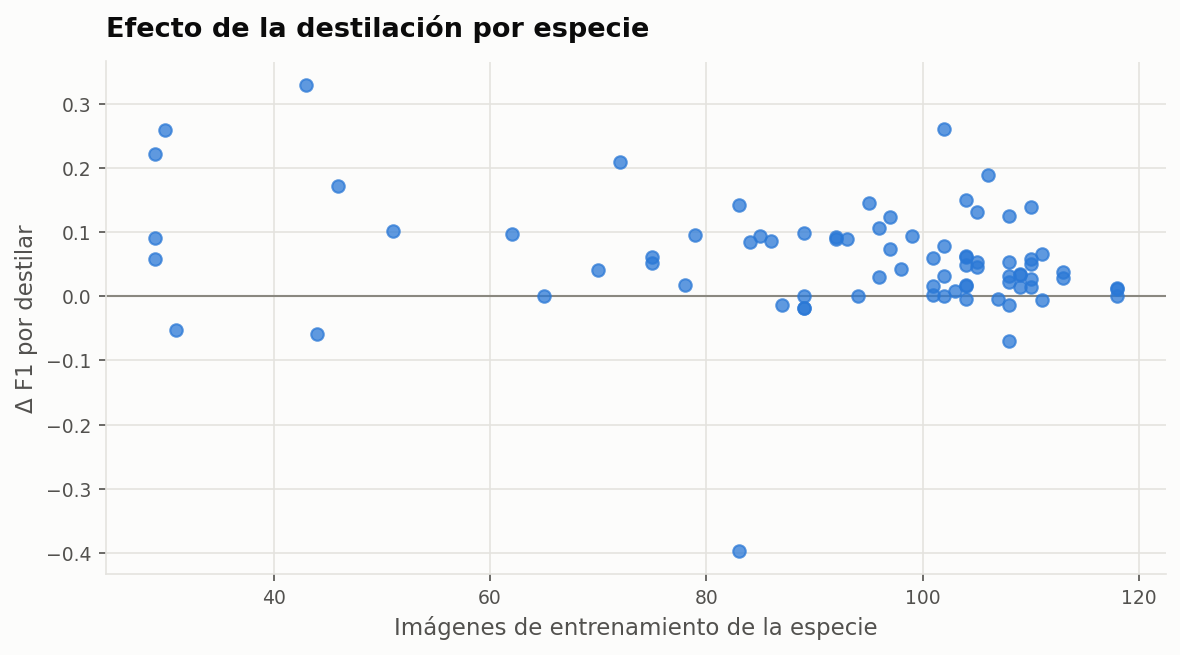

In [15]:
applyStyle()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axhline(0, color=INK_MUTED, linewidth=1)
ax.scatter(delta["n_train"], delta["delta_f1"], color=SERIE_1, alpha=0.75, zorder=3)
ax.set(xlabel="Imágenes de entrenamiento de la especie", ylabel="Δ F1 por destilar",
       title="Efecto de la destilación por especie")
fig.tight_layout()
plt.show()

## 5 · ¿Redujo la confusión intra-género?

Era la motivación original: los errores se concentran entre especies del mismo
género, y se esperaba que las etiquetas blandas del docente ayudaran ahí.

In [16]:
def intraGenero(metrica):
    mat = np.array(metrica["confusion_matrix"])
    generos = [c.split("_")[0] for c in metrica["class_names"]]
    errores = mat.sum() - np.trace(mat)
    intra = sum(mat[i][j] for i in range(len(generos)) for j in range(len(generos))
                if i != j and generos[i] == generos[j])
    return intra, errores

mDoc = registro.loadRunMetrics(
    registro.loadRunConfig(caso["destilado"])["distillation"]["teacher_run_id"]
)["splits"]["test"]

filas = []
for nombre, m in (("control", mCtrl), ("destilado", mDest), ("docente", mDoc)):
    intra, errores = intraGenero(m)
    filas.append({"modelo": nombre, "errores": int(errores), "intra_genero": int(intra),
                  "fraccion": round(intra / errores, 3)})
pd.DataFrame(filas)

,modelo,errores,intra_genero,fraccion
0,control,461,132,0.286
1,destilado,345,129,0.374
2,docente,177,89,0.503


## 6 · Calidad del docente como fuente de etiquetas blandas

La destilación solo puede transferir lo que el docente sabe. Si su ventaja es
estrecha, o si se equivoca justo donde el problema es difícil, las etiquetas
blandas aportan poco y arrastran su sesgo.

In [17]:
yt, yp = np.array(mDoc["y_true"]), np.array(mDoc["y_pred"])
intraDoc, errDoc = intraGenero(mDoc)
intraCtrl, errCtrl = intraGenero(mCtrl)

print(f"  el docente falla en {(yt != yp).sum()}/{len(yt)} imágenes de test ({(yt != yp).mean():.1%})")
print(f"  ventaja del docente sobre el estudiante: {caso['brecha']:+.4f} de macro-F1")
print(f"  de sus errores, {intraDoc/errDoc:.1%} son intra-género, "
      f"contra {intraCtrl/errCtrl:.1%} del estudiante sin destilar")

  el docente falla en 177/2062 imágenes de test (8.6%)
  ventaja del docente sobre el estudiante: +0.1443 de macro-F1
  de sus errores, 50.3% son intra-género, contra 28.6% del estudiante sin destilar


## Conclusión

Se llena al ejecutar, con los números de arriba. Los tres factores a revisar
cuando la destilación no aporta:

1. **Ventaja del docente**: si la brecha con el estudiante es estrecha, hay poco
   que transferir.
2. **Dónde se equivoca el docente**: si sus errores se concentran justo en la
   distinción difícil (intra-género), imitarlo importa esa debilidad.
3. **Backbone congelado**: con el backbone fijo solo se entrena la cabeza, así
   que la destilación no puede mover las representaciones — que es su mecanismo
   principal — sino apenas la frontera de decisión.